# Import Libarary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

%matplotlib inline

# Import data

In [2]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

In [3]:
df = pd.read_csv(data)
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [4]:
n = len(df) # Check numnber of rows in dataset.
print(f'total: {n} rows')

total: 5000 rows


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   object 
 1   industry                  4760 non-null   object 
 2   employment_status         4806 non-null   object 
 3   location                  4792 non-null   object 
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [6]:
df.describe() # Describe basic statistics

,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
count,4631.000000,5000.000000,5000.000000,4965.000000,5000.000000
mean,54533.212049,2.089400,4.472600,0.494767,0.576600
std,21245.661710,1.188987,2.435906,0.199431,0.494147
min,12000.000000,0.000000,0.000000,0.010000,0.000000
25%,40458.500000,1.000000,3.000000,0.360000,0.000000
50%,55051.000000,2.000000,4.000000,0.490000,1.000000
75%,71252.500000,3.000000,6.000000,0.630000,1.000000
max,109886.000000,6.000000,13.000000,0.990000,1.000000


In [7]:
df.dtypes

,0
lead_source,object
industry,object
employment_status,object
location,object
annual_income,float64
number_of_courses_viewed,int64
interaction_count,int64
lead_score,float64
converted,int64


# Data preparation

Check if the missing values are presented in the features.

In [8]:
df.isnull().sum()

,0
lead_source,148
industry,240
employment_status,194
location,208
annual_income,369
number_of_courses_viewed,0
interaction_count,0
lead_score,35
converted,0


## For categorical features, replace them with 'NA'

In [9]:
categorical_features = list(df.dtypes[df.dtypes == 'object'].index) # Store the names of object columns in categorical_features
df[categorical_features] = df[categorical_features].fillna('NA') # Fill NA to missing value in categorical features.

## For numerical features, replace with with 0.0

In [10]:
numerical_features = list(df.dtypes[df.dtypes == 'float64'].index) # Store the names of int64 columns in numerical_features
df[numerical_features] = df[numerical_features].fillna(0.0) # Fill NA to missing value in numerical_features.

In [11]:
df.isnull().sum()

,0
lead_source,0
industry,0
employment_status,0
location,0
annual_income,0
number_of_courses_viewed,0
interaction_count,0
lead_score,0
converted,0


# Split the data into 3 parts

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [14]:
y_full_train = df_full_train.pop('converted') # Move the target column from df_full_train to y_full_train
y_train = df_train.pop('converted') # Move the target column from df_train to y_train
y_val = df_val.pop('converted') # Move the target column from df_val to y_val
y_test = df_test.pop('converted') # Move the target column from df_test to y_test

In [15]:
print('Train:', len(df_train))
print('Validation:', len(df_val))
print('Test:', len(df_test))

Train: 3000
Validation: 1000
Test: 1000


# Question 1: ROC AUC feature importance

Which numerical variable (among the following 4) has the highest AUC?

In [16]:
from sklearn.metrics import roc_auc_score  # Import the function used to calculate ROC AUC

columns = [
    'lead_score',
    'number_of_courses_viewed',
    'interaction_count',
    'annual_income'
]  # Select only the four features listed in the question

auc_scores = {}  # Create a dictionary to store the scores

for column in columns:  # Check each of the four features
    auc = roc_auc_score(y_train, df_train[column])  # Use feature values as scores and training targets as ground truth

    if auc < 0.5:  # Reverse the ranking if AUC is below 0.5
        auc = roc_auc_score(y_train, -df_train[column])

    auc_scores[column] = auc  # Store the final AUC without rounding

auc_scores = pd.Series(auc_scores).sort_values(ascending=False)  # Sort scores from highest to lowest
display(auc_scores)  # Display the scores

print('Highest AUC:', auc_scores.idxmax())  # Print the feature with the highest AUC

,0
lead_score,0.788225
interaction_count,0.764920
number_of_courses_viewed,0.722989
annual_income,0.608198


Highest AUC: lead_score


# Question 2: Training the model
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

In [17]:
from sklearn.feature_extraction import DictVectorizer  # Import the tool used to encode categorical features
from sklearn.linear_model import LogisticRegression  # Import the logistic regression model
from sklearn.metrics import roc_auc_score  # Import the function used to calculate ROC AUC

train_dicts = df_train.to_dict(orient='records')  # Convert training rows into dictionaries
val_dicts = df_val.to_dict(orient='records')  # Convert validation rows into dictionaries

dv = DictVectorizer(sparse=False)  # Create a vectorizer that returns a dense array
X_train = dv.fit_transform(train_dicts)  # Learn feature columns and encode training data
X_val = dv.transform(val_dicts)  # Encode validation data using the same feature columns

model = LogisticRegression(
    solver='liblinear',  # Use liblinear to find the model weights
    C=1.0,  # Set the inverse regularization strength
    max_iter=1000  # Allow up to 1000 optimization iterations
)
model.fit(X_train, y_train)  # Train the model using training features and targets

y_pred = model.predict_proba(X_val)[:, 1]  # Get the predicted probability of Class 1
auc = roc_auc_score(y_val, y_pred)  # Calculate validation AUC using probabilities

print('Validation AUC:', round(auc, 3))  # Print AUC rounded to 3 decimal places

Validation AUC: 0.732


# Question 3: Precision and Recall

Now let's compute precision and recall for our model.

Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
For each threshold, compute precision and recall
Plot them

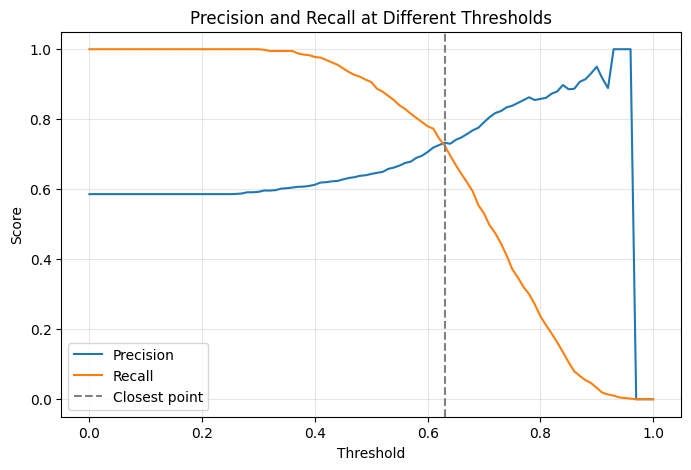

Threshold: 0.63
Precision: 0.7327586206896551
Recall: 0.7252559726962458


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.0, 1.0, 101)  # Create thresholds from 0.00 to 1.00 with step 0.01
results_q3 = []  # Create a list to store the results

for threshold in thresholds:  # Evaluate each threshold
    predictions = (y_pred >= threshold)  # Convert probabilities into predicted classes

    precision = precision_score(y_val, predictions, zero_division=0)  # Calculate precision; use 0 if undefined
    recall = recall_score(y_val, predictions, zero_division=0)  # Calculate recall; use 0 if undefined

    results_q3.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'difference': abs(precision - recall)  # Calculate the absolute difference
    })

results_q3 = pd.DataFrame(results_q3)  # Convert results into a table

valid_results = results_q3[
    (results_q3['precision'] != 0) | (results_q3['recall'] != 0)
]  # Exclude thresholds where both metrics are zero

best = valid_results.loc[
    valid_results['difference'].idxmin()
]  # Find the threshold with the smallest absolute difference

plt.figure(figsize=(8, 5))  # Create a figure
plt.plot(results_q3['threshold'], results_q3['precision'], label='Precision')
plt.plot(results_q3['threshold'], results_q3['recall'], label='Recall')
plt.axvline(best['threshold'], color='gray', linestyle='--', label='Closest point')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall at Different Thresholds')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Threshold:', round(best['threshold'], 2))  # Print the selected threshold
print('Precision:', best['precision'])
print('Recall:', best['recall'])

In [19]:
display(
    results_q3.style.format({
        'threshold': '{:.2f}',
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'difference': '{:.4f}'
    })
)  # Display all thresholds with precision, recall, and absolute difference

,threshold,precision,recall,difference
0,0.00,0.5860,1.0000,0.4140
1,0.01,0.5860,1.0000,0.4140
2,0.02,0.5860,1.0000,0.4140
3,0.03,0.5860,1.0000,0.4140
4,0.04,0.5860,1.0000,0.4140
5,0.05,0.5860,1.0000,0.4140
6,0.06,0.5860,1.0000,0.4140
7,0.07,0.5860,1.0000,0.4140
8,0.08,0.5860,1.0000,0.4140
9,0.09,0.5860,1.0000,0.4140


# Question 4: F1 score

At which threshold F1 is maximal?

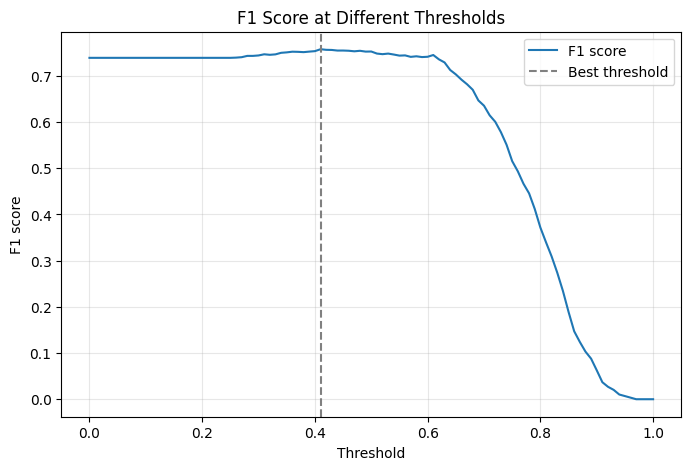

Best threshold: 0.41
Maximum F1: 0.7576158940397352


In [20]:
results_q4 = results_q3.copy()  # Copy the precision and recall results from Q3

denominator = results_q4['precision'] + results_q4['recall']  # Calculate the denominator

results_q4['f1'] = (
    2 * results_q4['precision'] * results_q4['recall']
    / denominator.replace(0, np.nan)
).fillna(0)  # Calculate F1; use 0 when precision and recall are both zero

best = results_q4.loc[results_q4['f1'].idxmax()]  # Find the threshold with the highest F1

plt.figure(figsize=(8, 5))  # Create a figure
plt.plot(results_q4['threshold'], results_q4['f1'], label='F1 score')
plt.axvline(best['threshold'], color='gray', linestyle='--', label='Best threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.title('F1 Score at Different Thresholds')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Best threshold:', round(best['threshold'], 2))  # Print the threshold with the highest F1
print('Maximum F1:', best['f1'])  # Print the highest F1 score

In [21]:
display(
    results_q4.loc[
        [results_q4['f1'].idxmax()],
        ['threshold', 'precision', 'recall', 'f1']
    ].style.format({
        'threshold': '{:.2f}',
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'f1': '{:.4f}'
    })
)  # Display the threshold with the highest F1 score

,threshold,precision,recall,f1
41,0.41,0.6190,0.9761,0.7576


# Question 5: 5-Fold CV
How large is standard deviation of the scores across different folds?

In [22]:
from sklearn.model_selection import KFold  # Import the tool used to split data into folds

kfold = KFold(n_splits=5, shuffle=True, random_state=1)  # Create 5 reproducible folds
scores = []  # Create a list to store AUC scores

for fold, (train_idx, val_idx) in enumerate(kfold.split(df_full_train), start=1):
    df_train_fold = df_full_train.iloc[train_idx]  # Select training features for this fold
    df_val_fold = df_full_train.iloc[val_idx]  # Select validation features for this fold

    y_train_fold = y_full_train.iloc[train_idx]  # Select the matching training targets
    y_val_fold = y_full_train.iloc[val_idx]  # Select the matching validation targets

    dv_fold = DictVectorizer(sparse=False)  # Create a new encoder for this fold
    X_train_fold = dv_fold.fit_transform(
        df_train_fold.to_dict(orient='records')
    )  # Learn feature columns and encode training data
    X_val_fold = dv_fold.transform(
        df_val_fold.to_dict(orient='records')
    )  # Encode validation data using the same columns

    model_fold = LogisticRegression(
        solver='liblinear',
        C=1.0,
        max_iter=1000
    )  # Create a model with the required parameters
    model_fold.fit(X_train_fold, y_train_fold)  # Train the model

    predictions = model_fold.predict_proba(X_val_fold)[:, 1]  # Get probabilities for Class 1
    auc = roc_auc_score(y_val_fold, predictions)  # Calculate validation AUC
    scores.append(auc)  # Store the score

results_q5 = pd.DataFrame({
    'fold': range(1, 6),
    'auc': scores
})  # Create a table of fold scores

display(results_q5)  # Display AUC for each fold
print('Mean AUC:', np.mean(scores))  # Print the average AUC
print('Standard deviation:', round(np.std(scores), 3))  # Print standard deviation rounded to 3 decimals

,fold,auc
0,1,0.730560
1,2,0.729573
2,3,0.736343
3,4,0.741245
4,5,0.720914


Mean AUC: 0.7317269710972524
Standard deviation: 0.007


# Question 6: Hyperparameter Tuning
Which C leads to the best mean ROC AUC?

In [23]:
C_values = [0.000001, 0.001, 1]  # Store the C values to test
results_q6 = []  # Create a list to store the results

for C in C_values:  # Evaluate each C value
    kfold = KFold(
        n_splits=5,
        shuffle=True,
        random_state=1
    )  # Use the same fold splits for every C value

    scores = []  # Create a list to store AUC scores for this C

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train_fold = df_full_train.iloc[train_idx]  # Select training features
        df_val_fold = df_full_train.iloc[val_idx]  # Select validation features

        y_train_fold = y_full_train.iloc[train_idx]  # Select matching training targets
        y_val_fold = y_full_train.iloc[val_idx]  # Select matching validation targets

        dv_fold = DictVectorizer(sparse=False)  # Create a new encoder for this fold
        X_train_fold = dv_fold.fit_transform(
            df_train_fold.to_dict(orient='records')
        )  # Learn feature columns and encode training data
        X_val_fold = dv_fold.transform(
            df_val_fold.to_dict(orient='records')
        )  # Encode validation data using the same columns

        model_fold = LogisticRegression(
            solver='liblinear',
            C=C,
            max_iter=1000
        )  # Create a model using the current C value
        model_fold.fit(X_train_fold, y_train_fold)  # Train the model

        predictions = model_fold.predict_proba(X_val_fold)[:, 1]  # Get Class 1 probabilities
        auc = roc_auc_score(y_val_fold, predictions)  # Calculate validation AUC
        scores.append(auc)  # Store the fold score

    results_q6.append({
        'C': C,
        'mean_auc': round(np.mean(scores), 3),  # Round mean AUC to 3 decimals
        'std_auc': round(np.std(scores), 3)  # Round standard deviation to 3 decimals
    })

results_q6 = pd.DataFrame(results_q6)  # Convert results into a table

results_q6 = results_q6.sort_values(
    by=['mean_auc', 'std_auc', 'C'],
    ascending=[False, True, True]
)  # Choose highest mean, then lowest std, then smallest C

display(results_q6)  # Display results in selection order
print('Best C:', results_q6.iloc[0]['C'])  # Print the selected C

,C,mean_auc,std_auc
1,0.001000,0.749,0.010
2,1.000000,0.732,0.007
0,0.000001,0.617,0.019


Best C: 0.001
